# Trabajo Práctico 2 - Computer Vision 1

## Nicolás Granato

Objetivo: Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que usan las cámaras digitales modernas.

## 1. Implementación de la métrica FM (Frequency domain blur Measure) propuesta en:
"Image Sharpness Measure for Blurred Images in Frequency Domain", Procedia Engineering 64 (2013) 149–158.

### Algoritmo FM
Dado un frame/región I de tamaño M×N:
1. F = FFT2(I) → Pasa la imagen al dominio de frecuencias — las frecuencias altas son bordes/detalles
2. Fc = fftshift(F)  → origen al centro
3. AF = |Fc| → Descarta la fase, queda solo la magnitud de cada componente frecuencial
4. M_max = max(AF) → Referencia adaptativa (el pico de energía, generalmente la DC)
5. TH = #{píxeles : AF > M_max/1000} → Cuenta cuántas frecuencias son "significativas" — umbral empírico del paper
6. **FM = TH / (M × N)** → Normaliza por resolución

Un frame más nítido → mayor FM (más componentes de alta frecuencia).

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

VIDEO_PATH = "focus_video.mov"

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Métrica FM y funciones auxiliares

In [2]:
def compute_FM(region):
    """
    Calcula la métrica FM (Frequency domain blur Measure).
    Input : región de imagen I de tamaño M×N (BGR o escala de grises)
    Output: FM ∈ [0, 1]  —  mayor valor = imagen más nítida
    """

    # Convertir a escala de grises
    gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY) if region.ndim == 3 else region
    gray = gray.astype(np.float32)   # float para la FFT

    # Paso 1
    # Calcular F: la Transformada de Fourier de la imagen.
    F = np.fft.fft2(gray)

    # Paso 2
    # Calcular Fc: desplazar el origen de F al centro de la imagen (fftshift).
    # Por defecto la FFT pone la componente DC (frecuencia 0) en la esquina superior-izquierda. 
    # Al centrarla, las bajas frecuencias quedan en el centro y las altas en la periferia.
    Fc = np.fft.fftshift(F)

    # Paso 3
    # Calcular AF = |Fc|: el valor absoluto (magnitud) del espectro centrado.
    # Descarta la fase y conserva solo la amplitud de cada componente frecuencial. 
    AF = np.abs(Fc)

    # Paso 4
    # Calcular M = max(AF): el valor máximo del espectro de magnitud.
    M_max = AF.max()
    if M_max == 0:
        return 0.0

    # Paso 5
    # Calcular TH: cantidad de píxeles en AF cuyo valor supera el umbral.
    # El umbral se fija en thres = M / 1000.
    thres = M_max / 1000.0
    TH = np.sum(AF > thres)

    # Paso 6
    # Calcular FM (ecuación 1 del paper):
    #        FM = TH / (M × N)
    # Se normaliza por el total de píxeles para que FM sea independiente de la resolución de la imagen y comparable entre distintos tamaños.
    rows, cols = gray.shape
    FM = float(TH) / (rows * cols)

    return FM


def find_focus_region(fm, threshold_pct=0.70):
    """
    Delimita la región de enfoque: frames donde FM >= threshold_pct * max(FM).
    Devuelve (start_frame, end_frame, threshold_value).
    """
    thresh = threshold_pct * fm.max()
    indices = np.where(fm >= thresh)[0]
    if len(indices) == 0:
        return 0, len(fm) - 1, thresh
    return int(indices[0]), int(indices[-1]), float(thresh)


print("Todo ok")

Todo ok


## Info del video y configuración de ROIs

In [3]:
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"No se pudo abrir: {VIDEO_PATH}"

TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FPS          = cap.get(cv2.CAP_PROP_FPS)
W            = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

print(f"Frames: {TOTAL_FRAMES}  |  FPS: {FPS:.1f}  |  Resolución: {W}×{H}  |  Duración: {TOTAL_FRAMES/FPS:.1f} s")

# 1.2: ROI central con 10% del área total, misma relación de aspecto que el frame completo.
SCALE = np.sqrt(0.10)
roi_w = int(W * SCALE)
roi_h = int(H * SCALE)
cx, cy = W // 2, H // 2
ROI = (cx - roi_w // 2, cy - roi_h // 2,
       cx + roi_w // 2, cy + roi_h // 2)
print(f"\nROI central: {roi_w}×{roi_h} px  →  {roi_w*roi_h/(W*H):.1%} del área total")

# 1.3: Grilla 5×5 de bloques cuadrados pequeños centrados ---
# Área total de los 25 bloques = 10% del frame  →  área de cada bloque = 0.4%
NR, NC     = 5, 5
N_BLOCKS   = NR * NC                            # 25
block_area = 0.10 * W * H / N_BLOCKS
block_side = int(np.sqrt(block_area))           # lado del bloque cuadrado
step       = int(block_side * 1.7)              # separación centro a centro

# Posición del bloque (r, c) dentro de la grilla centrada
grid_span_x = (NC - 1) * step
grid_span_y = (NR - 1) * step
x0 = cx - grid_span_x // 2
y0 = cy - grid_span_y // 2

BLOCKS = []  # lista de (x1, y1, x2, y2) para cada uno de los 25 bloques
for r in range(NR):
    for c in range(NC):
        bx = x0 + c * step
        by = y0 + r * step
        BLOCKS.append((bx - block_side // 2, by - block_side // 2,
                        bx + block_side // 2, by + block_side // 2))

total_block_area = N_BLOCKS * block_side ** 2
print(f"Grilla {NR}×{NC}: bloque {block_side}×{block_side} px  |  "
      f"step={step} px  |  área total bloques={total_block_area/(W*H):.1%}")

Frames: 171  |  FPS: 30.0  |  Resolución: 640×360  |  Duración: 5.7 s

ROI central: 202×113 px  →  9.9% del área total
Grilla 5×5: bloque 30×30 px  |  step=51 px  |  área total bloques=9.8%


### Visualización de referencia: ROIs sobre el frame 1

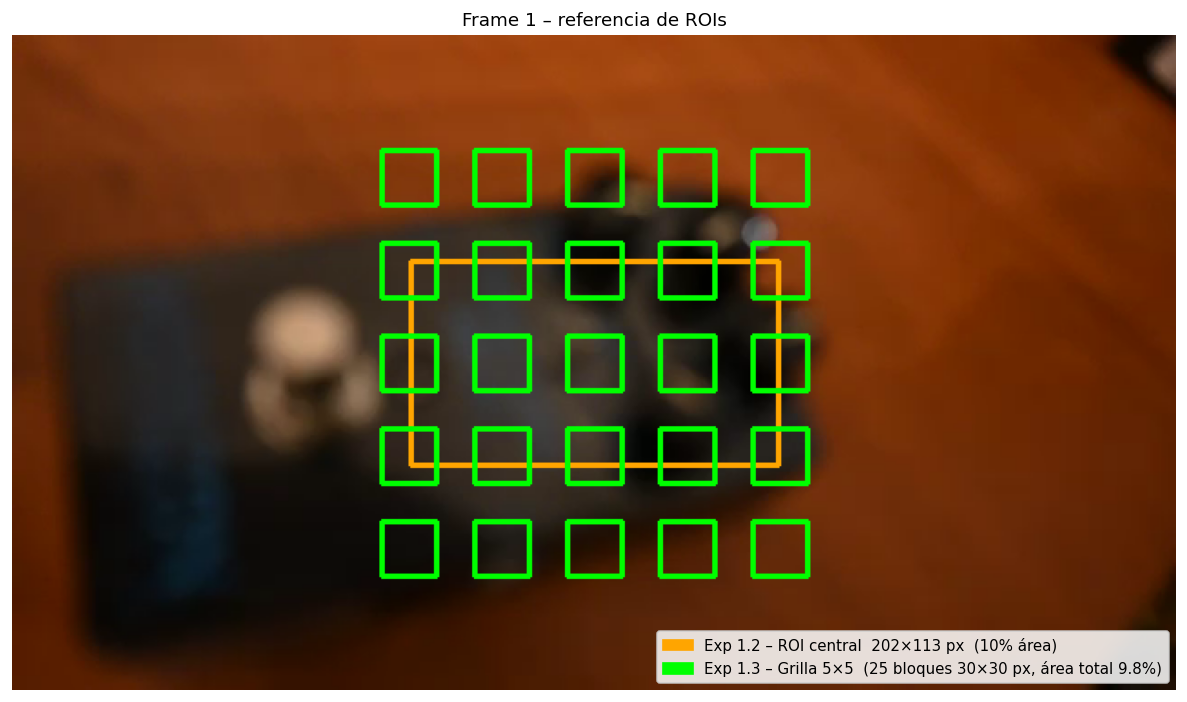

In [4]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, frame0 = cap.read()
cap.release()

vis0 = frame0.copy()

# 1.2 – ROI central (naranja)
x1, y1, x2, y2 = ROI
cv2.rectangle(vis0, (x1, y1), (x2, y2), (0, 165, 255), 2)

# 1.3 – 25 bloques de la matriz (verde)
for (bx1, by1, bx2, by2) in BLOCKS:
    cv2.rectangle(vis0, (bx1, by1), (bx2, by2), (0, 255, 0), 2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(cv2.cvtColor(vis0, cv2.COLOR_BGR2RGB))
ax.axis('off')
ax.set_title('Frame 1 – referencia de ROIs', fontsize=11)

patches = [
    mpatches.Patch(color='orange', label=f'Exp 1.2 – ROI central  {roi_w}×{roi_h} px  (10% área)'),
    mpatches.Patch(color='lime',   label=f'Exp 1.3 – Grilla {NR}×{NC}  ({N_BLOCKS} bloques {block_side}×{block_side} px, área total {N_BLOCKS*block_side**2/(W*H):.1%})'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.show()

### Procesamiento del video: los 3 experimentos

In [5]:
fm_full = []   # 1.1 – frame completo
fm_roi  = []   # 1.2 – ROI central 10%
fm_grid = []   # 1.3 – grilla 5×5 (25 bloques pequeños, área total 10%)

cap = cv2.VideoCapture(VIDEO_PATH)
n = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 1.1 Frame completo
    fm_full.append(compute_FM(frame))

    # 1.2 ROI central
    x1, y1, x2, y2 = ROI
    fm_roi.append(compute_FM(frame[y1:y2, x1:x2]))

    # 1.3 Grilla: FM de cada bloque → promedio de los 25
    scores = [compute_FM(frame[y1:y2, x1:x2]) for (x1, y1, x2, y2) in BLOCKS]
    fm_grid.append(float(np.mean(scores)))

    n += 1
    if n % 25 == 0:
        print(f"  Frame {n}/{TOTAL_FRAMES} ...", end="\r")

cap.release()

fm_full  = np.array(fm_full)
fm_roi   = np.array(fm_roi)
fm_grid  = np.array(fm_grid)
frames   = np.arange(len(fm_full))

print(f"\nProcesados {len(frames)} frames")
print(f"\n{'Experimento':<22} {'Peak frame':>10}  {'FM max':>8}")
print("-" * 45)
for name, fm in [("Full frame", fm_full), ("ROI central", fm_roi), ("Grilla 5×5", fm_grid)]:
    print(f"{name:<22} {fm.argmax():>10d}  {fm.max():>8.4f}")

  Frame 150/171 ...
Procesados 171 frames

Experimento            Peak frame    FM max
---------------------------------------------
Full frame                    109    0.0286
ROI central                   111    0.3560
Grilla 5×5                     91    0.6707


### Visualización: curvas de enfoque frame a frame

In [6]:
# Defino la región de enfoque como los frames donde FM ≥ 85% del máximo

THRESHOLD_PCT = 0.85   

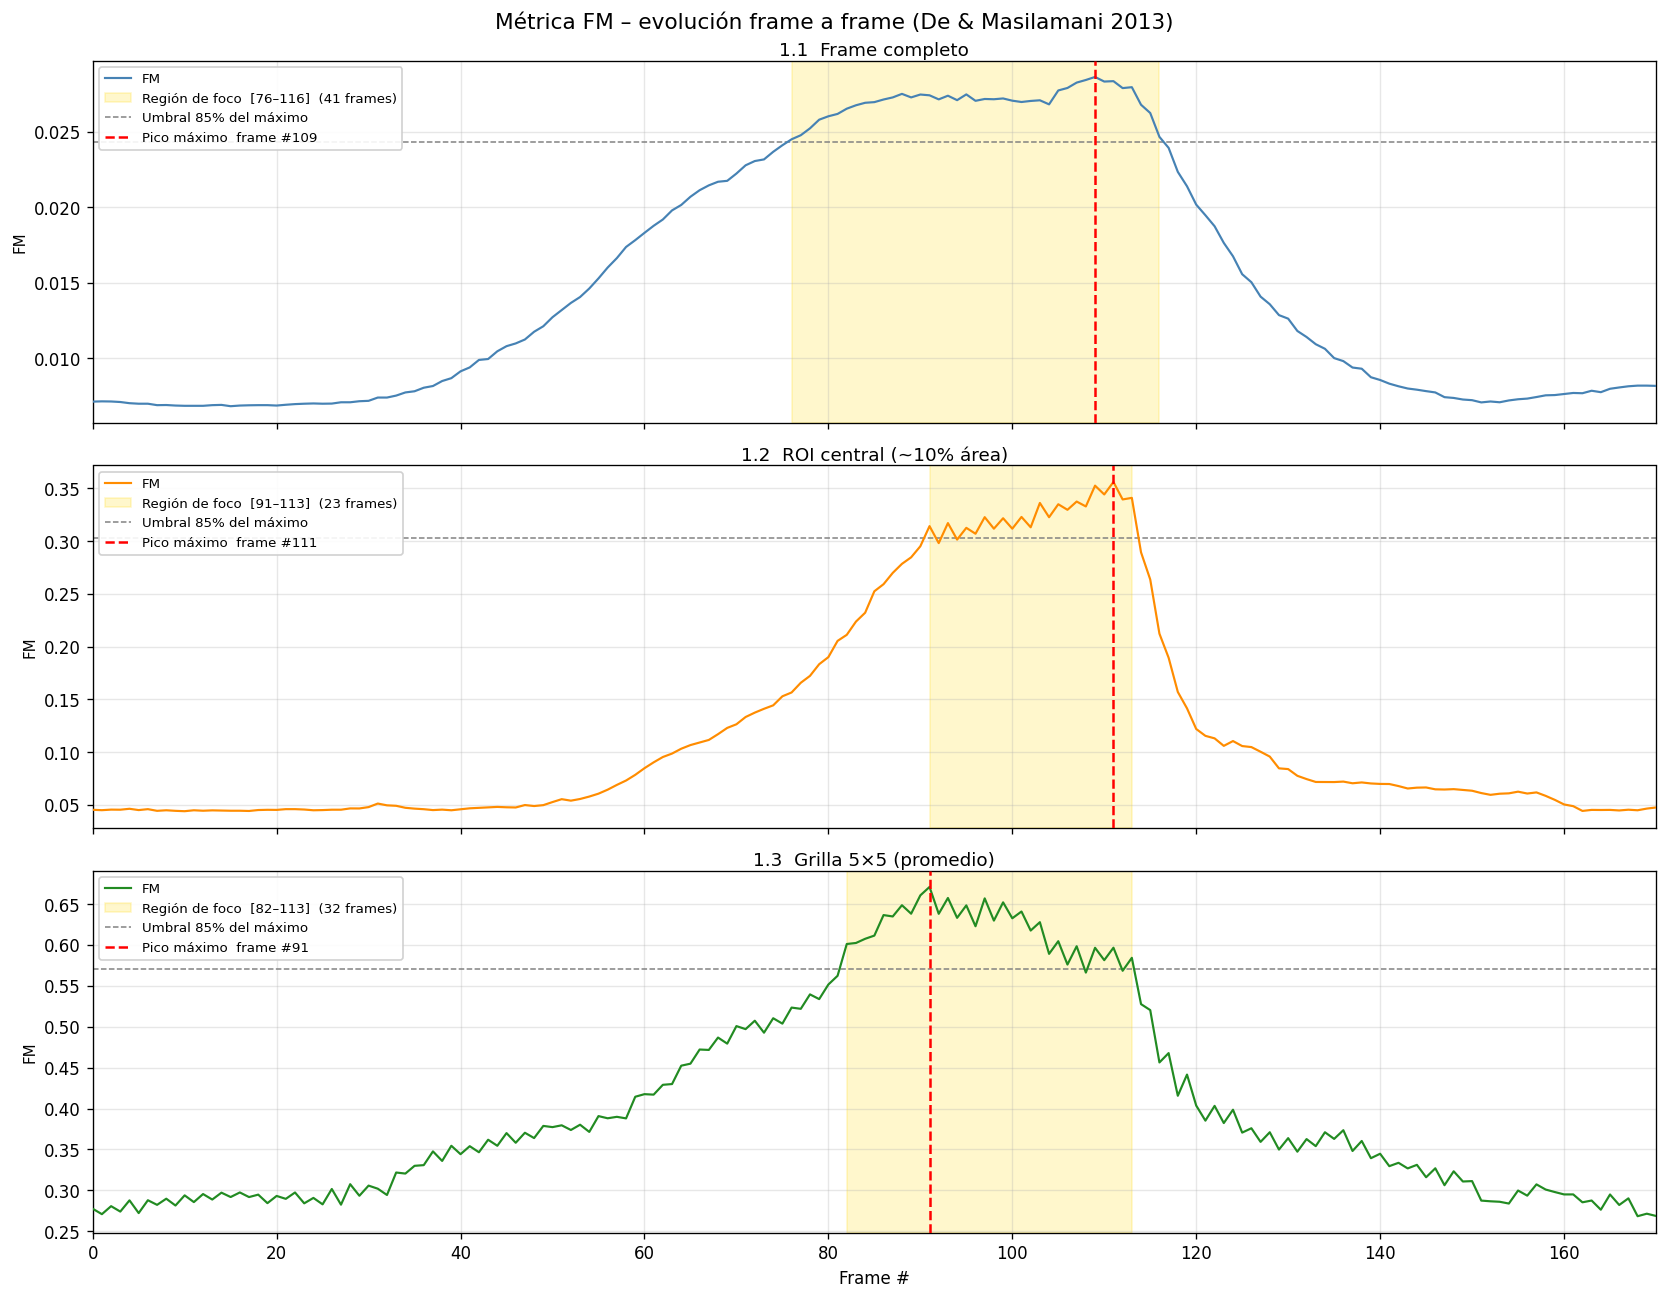

Guardado: tp2_exp1_curvas.png


In [7]:
configs = [
    (fm_full, '1.1  Frame completo',          'steelblue'),
    (fm_roi,  '1.2  ROI central (~10% área)', 'darkorange'),
    (fm_grid, f'1.3  Grilla {NR}×{NC} (promedio)', 'forestgreen'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Métrica FM – evolución frame a frame (De & Masilamani 2013)', fontsize=13)

for ax, (fm, title, color) in zip(axes, configs):
    start, end, thresh = find_focus_region(fm, THRESHOLD_PCT)
    peak = int(fm.argmax())

    ax.plot(frames, fm, color=color, lw=1.3, zorder=3, label='FM')

    # Región de foco resaltada
    ax.axvspan(start, end, alpha=0.20, color='gold',
               label=f'Región de foco  [{start}–{end}]  ({end-start+1} frames)')

    # Línea de umbral
    ax.axhline(thresh, color='gray', lw=0.9, ls='--', zorder=2,
               label=f'Umbral {THRESHOLD_PCT:.0%} del máximo')

    # Línea de pico
    ax.axvline(peak, color='red', lw=1.5, ls='--', zorder=4,
               label=f'Pico máximo  frame #{peak}')

    ax.set_title(title, fontsize=11, pad=3)
    ax.set_ylabel('FM', fontsize=9)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax.set_xlim(0, len(frames) - 1)

axes[-1].set_xlabel('Frame #', fontsize=10)
plt.tight_layout()
plt.savefig('tp2_exp1_curvas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: tp2_exp1_curvas.png")

Se puede ver la evolución de la métrica a lo largo del tiempo del video, lo curioso es que no solo el puntomáximo es diferente, sino que los rangos también. Quizás se deba a que el objeto está en la región central de la mesa y más cercano a la cámara, lo que hace que el efecto de desenfoque pueda ser diferente. Por eso (entiendo) es que en la grilla de 5x5 parecería ajustarse mejor.

Todavía en este punto falta normalizarlas.

### Comparación directa: las 3 curvas normalizadas

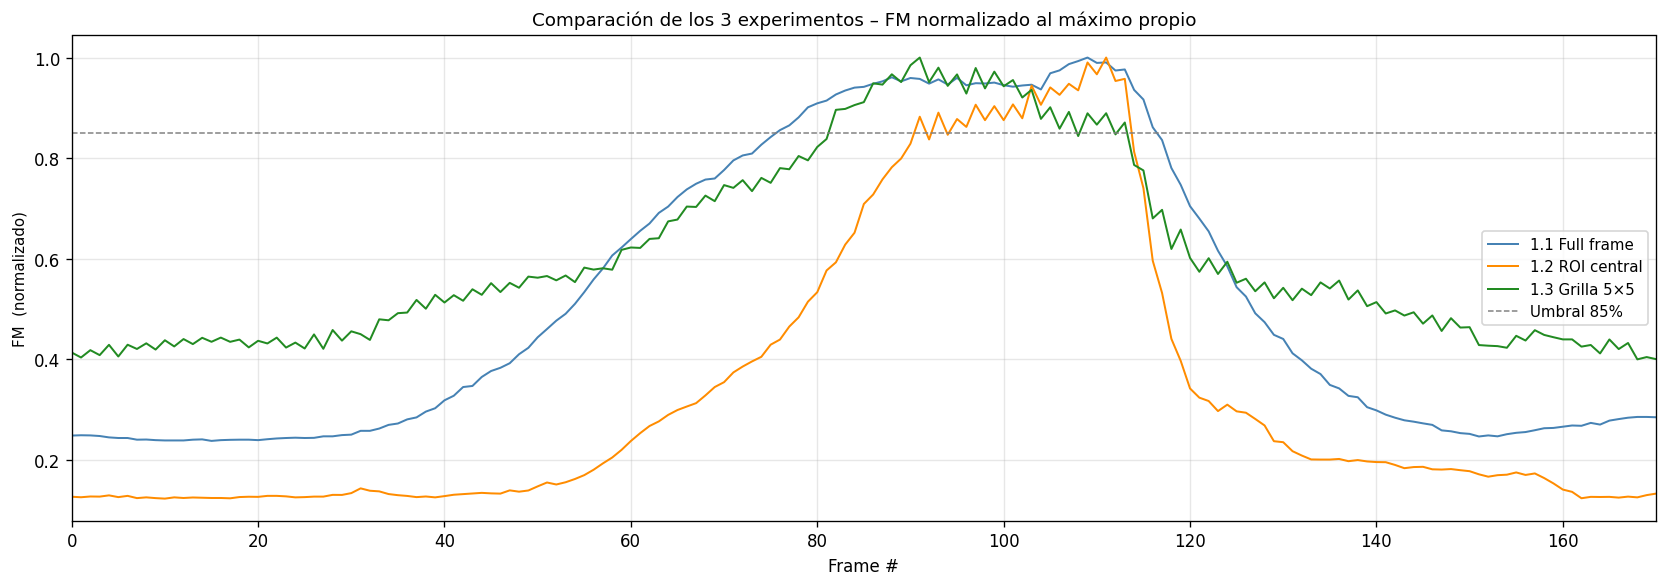

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

for fm, label, color in [
    (fm_full / fm_full.max(), '1.1 Full frame',        'steelblue'),
    (fm_roi  / fm_roi.max(),  '1.2 ROI central',       'darkorange'),
    (fm_grid / fm_grid.max(), f'1.3 Grilla {NR}×{NC}', 'forestgreen'),
]:
    ax.plot(frames, fm, lw=1.2, label=label, color=color)

ax.axhline(THRESHOLD_PCT, color='gray', ls='--', lw=0.9,
           label=f'Umbral {THRESHOLD_PCT:.0%}')
ax.set_xlabel('Frame #', fontsize=10)
ax.set_ylabel('FM  (normalizado)', fontsize=9)
ax.set_title('Comparación de los 3 experimentos – FM normalizado al máximo propio', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, len(frames) - 1)
plt.tight_layout()
plt.savefig('tp2_exp1_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Resumen de resultados y frame del pico de enfoque

In [9]:
print("=" * 62)
print(f"{'Experimento':<22} {'Peak':>6}  {'FM max':>8}  {'Región de foco':>20}")
print("=" * 62)
for name, fm in [("Full frame", fm_full), ("ROI central", fm_roi), ("Grilla 5×5", fm_grid)]:
    s, e, _ = find_focus_region(fm, THRESHOLD_PCT)
    print(f"{name:<22} {fm.argmax():>6d}  {fm.max():>8.4f}  [{s:>4d} – {e:>4d}] ({e-s+1} frames)")
print("=" * 62)
print(f"\nUmbral: FM ≥ {THRESHOLD_PCT:.0%} del máximo")
print(f"Video:  {len(frames)} frames @ {FPS:.1f} fps  →  {len(frames)/FPS:.1f} s")

Experimento              Peak    FM max        Región de foco
Full frame                109    0.0286  [  76 –  116] (41 frames)
ROI central               111    0.3560  [  91 –  113] (23 frames)
Grilla 5×5                 91    0.6707  [  82 –  113] (32 frames)

Umbral: FM ≥ 85% del máximo
Video:  171 frames @ 30.0 fps  →  5.7 s


Voy a tomar a la matriz de 25 bloques como mejor método de enfoque para volver a visualizar y guardar la imagen

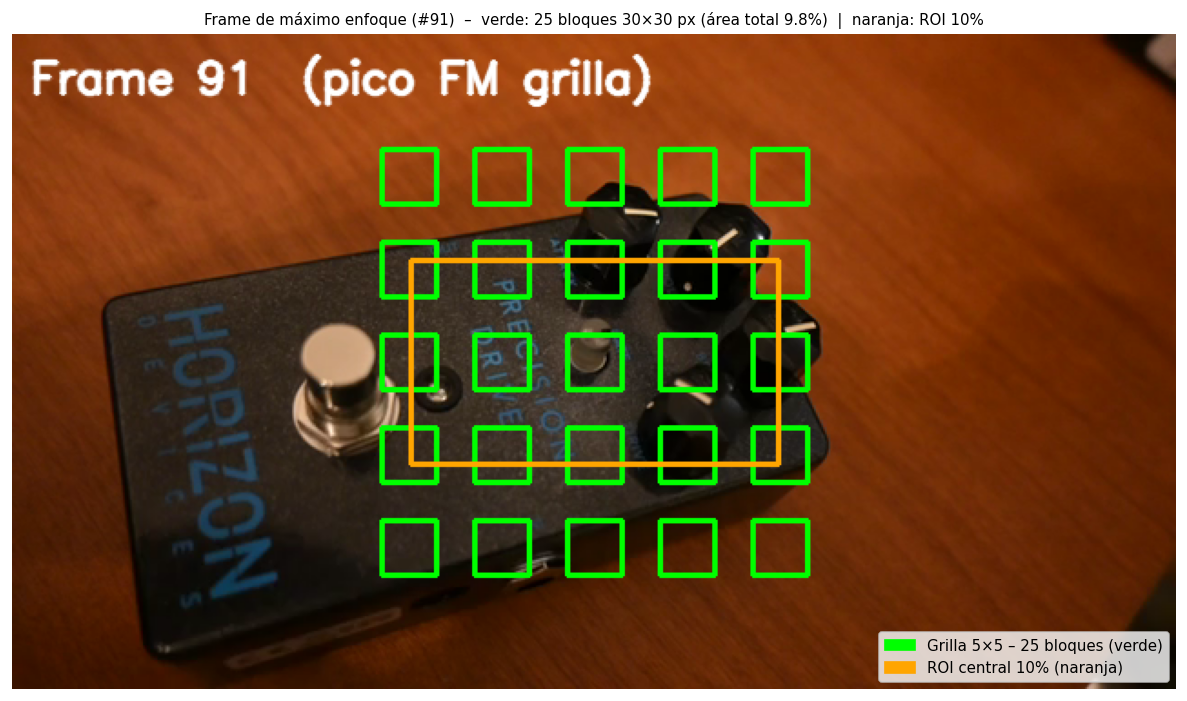

In [10]:
# Visualizar el frame de máximo enfoque con los 25 bloques y la ROI superpuestos
peak_idx = int(fm_grid.argmax())

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, peak_idx)
ret, peak_frame = cap.read()
cap.release()

vis = peak_frame.copy()

# 25 bloques de la grilla en verde
for (bx1, by1, bx2, by2) in BLOCKS:
    cv2.rectangle(vis, (bx1, by1), (bx2, by2), (0, 255, 0), 2)

# ROI central en naranja
x1, y1, x2, y2 = ROI
cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 165, 255), 2)

cv2.putText(vis, f'Frame {peak_idx}  (pico FM grilla)', (10, 32),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.axis('off')
ax.set_title(
    f'Frame de máximo enfoque (#{peak_idx})  –  '
    f'verde: {N_BLOCKS} bloques {block_side}×{block_side} px (área total {N_BLOCKS*block_side**2/(W*H):.1%})  |  '
    f'naranja: ROI 10%',
    fontsize=9
)
patches = [
    mpatches.Patch(color='lime',   label=f'Grilla {NR}×{NC} – {N_BLOCKS} bloques (verde)'),
    mpatches.Patch(color='orange', label='ROI central 10% (naranja)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('tp2_frame_pico.png', dpi=150, bbox_inches='tight')
plt.show()

### Unsharp Masking para expandir la zona de enfoque

Los frames apenas desenfocados (FM justo por debajo del umbral del 90%) contienen información de alta frecuencia que está levemente atenuada. 
unsharp masking amplifica esas frecuencias altas restando una versión suavizada al original:

```
sharpened = original + amount × (original − GaussianBlur(original))
```

Procedimiento:
1. Definir la zona apenas desenfocada con el mismo `THRESHOLD_PCT = 0.90`: frames donde `FM < 0.90 × max(FM)`.
2. Aplicar unsharp masking solo a esos frames.
3. Recalcular FM sobre los frames procesados.
4. Comparar la curva original vs. la curva con unsharp masking y cuantificar la expansión de la zona de foco.

In [11]:
def unsharp_mask(frame, sigma=1.0, amount=1.5):
    """
    Unsharp masking: sharpened = original + amount × (original − GaussianBlur(original))
    sigma  → dispersión del Gaussiano
    amount → intensidad del realce
    """
    blurred   = cv2.GaussianBlur(frame, (0, 0), sigma)
    sharpened = cv2.addWeighted(frame, 1.0 + amount, blurred, -amount, 0)
    return sharpened

# Umbrales: 
# THRESH_LOW  → por debajo: frame MUY desenfocado  → NO aplicar masking
# THRESH_HIGH → por encima: frame YA en foco       → NO aplicar masking
# Zona de masking: [THRESH_LOW, THRESH_HIGH)


THRESH_LOW  = 0.85
THRESH_HIGH = 0.95
SIGMA  = 1.0
AMOUNT = 1.5

#  Máscaras por experimento
def make_barely_mask(fm):
    mx = fm.max()
    return (fm >= THRESH_LOW * mx) & (fm < THRESH_HIGH * mx)

mask_full = make_barely_mask(fm_full)
mask_roi  = make_barely_mask(fm_roi)
mask_grid = make_barely_mask(fm_grid)

for name, mask in [("Full", mask_full), ("ROI", mask_roi), ("Grid", mask_grid)]:
    print(f"{name:<6}: {mask.sum():>3} frames con masking")

# Un solo recorrido del video
fm_unsharp_full = fm_full.copy()
fm_unsharp_roi  = fm_roi.copy()
fm_unsharp_grid = fm_grid.copy()

x1r, y1r, x2r, y2r = ROI
needs = mask_full | mask_roi | mask_grid

cap = cv2.VideoCapture(VIDEO_PATH)
for i in range(len(frames)):
    ret, frame = cap.read()
    if not ret:
        break
    if not needs[i]:
        continue

    if mask_full[i]:
        val = compute_FM(unsharp_mask(frame, SIGMA, AMOUNT))
        # Clampear al máximo original: el masking no puede "inventar" más nitidez
        # que el frame más enfocado del video sin procesar
        fm_unsharp_full[i] = min(val, fm_full.max())

    if mask_roi[i]:
        val = compute_FM(unsharp_mask(frame[y1r:y2r, x1r:x2r], SIGMA, AMOUNT))
        fm_unsharp_roi[i] = min(val, fm_roi.max())

    if mask_grid[i]:
        sharp  = unsharp_mask(frame, SIGMA, AMOUNT)
        scores = [compute_FM(sharp[y1:y2, x1:x2]) for (x1, y1, x2, y2) in BLOCKS]
        fm_unsharp_grid[i] = min(float(np.mean(scores)), fm_grid.max())

cap.release()
print("Procesamiento finalizado.")

Full  :  24 frames con masking
ROI   :  16 frames con masking
Grid  :  20 frames con masking
Procesamiento finalizado.


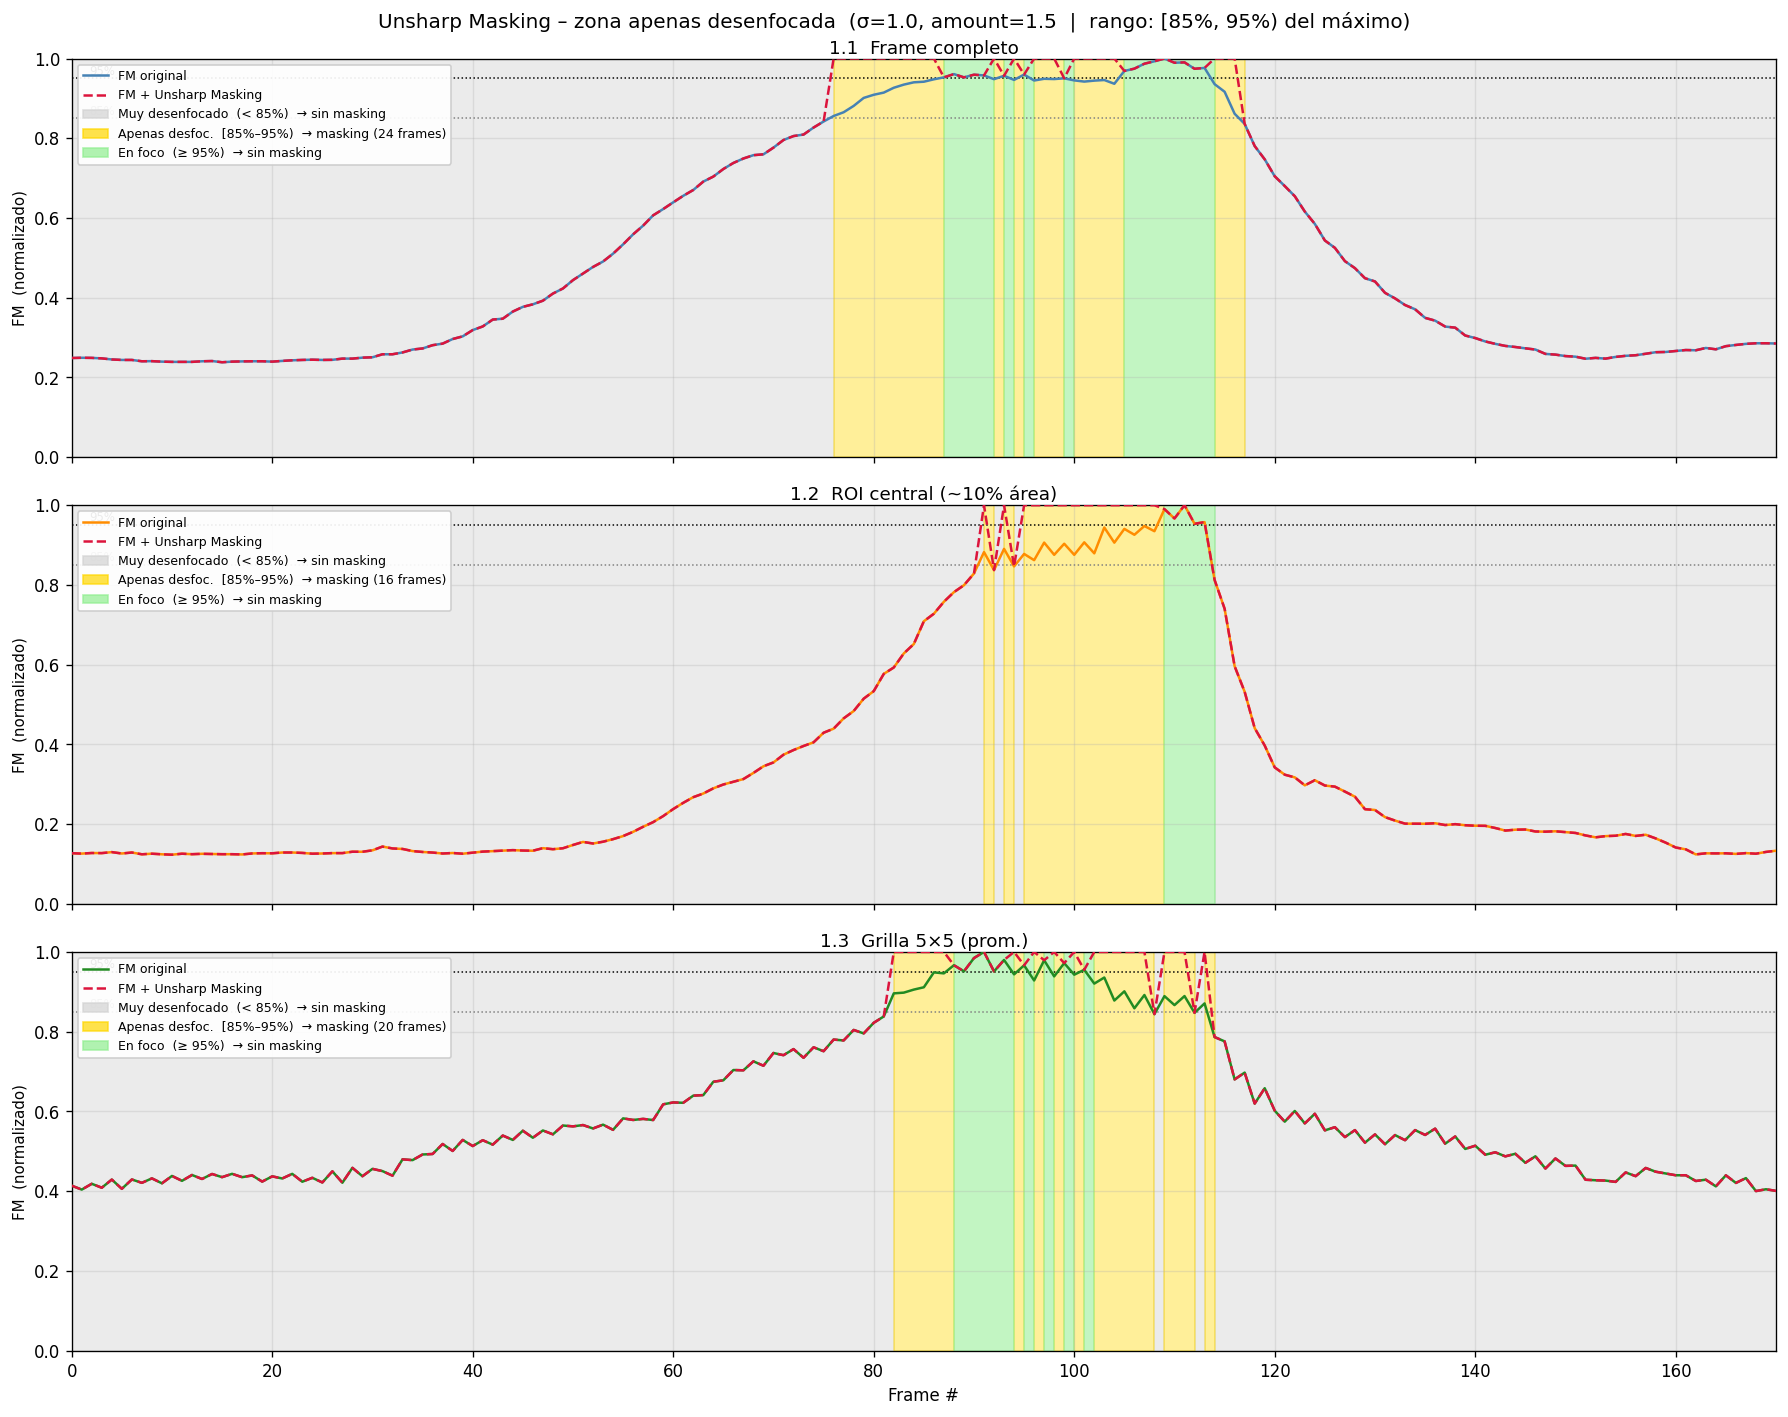

Guardado: tp2_unsharp.png


In [12]:
def contiguous_spans(mask):
    spans, in_span = [], False
    for i, v in enumerate(mask):
        if v and not in_span:
            start, in_span = i, True
        elif not v and in_span:
            spans.append((start, i - 1))
            in_span = False
    if in_span:
        spans.append((start, len(mask) - 1))
    return spans


experiments = [
    ('1.1  Frame completo',            fm_full,  fm_unsharp_full, mask_full,  'steelblue'),
    ('1.2  ROI central (~10% área)',    fm_roi,   fm_unsharp_roi,  mask_roi,   'darkorange'),
    (f'1.3  Grilla {NR}×{NC} (prom.)', fm_grid,  fm_unsharp_grid, mask_grid,  'forestgreen'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle(
    f'Unsharp Masking – zona apenas desenfocada  '
    f'(σ={SIGMA}, amount={AMOUNT}  |  rango: [{THRESH_LOW:.0%}, {THRESH_HIGH:.0%}) del máximo)',
    fontsize=12
)

for ax, (title, fm_orig, fm_sharp, mask, color) in zip(axes, experiments):
    mx = fm_orig.max()
    norm_orig  = fm_orig  / mx
    norm_sharp = fm_sharp / mx

    # Regiones de fondo
    # e+1 como límite derecho: axvspan(s, e) llega hasta la coordenada x=e,
    # pero el frame e visualmente ocupa hasta x=e+1, dejando huecos blancos
    # en cada transición. Con e+1 los spans se tocan sin gaps ni solapamientos.
    for s, e in contiguous_spans(fm_orig < THRESH_LOW * mx):
        ax.axvspan(s, e + 1, color='lightgray',  alpha=0.45, zorder=0)
    for s, e in contiguous_spans(mask):
        ax.axvspan(s, e + 1, color='gold',       alpha=0.40, zorder=0)
    for s, e in contiguous_spans(fm_orig >= THRESH_HIGH * mx):
        ax.axvspan(s, e + 1, color='lightgreen', alpha=0.55, zorder=0)

    # Curvas 
    ax.plot(frames, norm_orig,  color=color,     lw=1.5, zorder=3, label='FM original')
    ax.plot(frames, norm_sharp, color='crimson', lw=1.5, ls='--', zorder=4,
            label='FM + Unsharp Masking')

    # líneas de umbral
    ax.axhline(THRESH_LOW,  color='gray',  lw=0.9, ls=':')
    ax.axhline(THRESH_HIGH, color='black', lw=0.9, ls=':')
    ax.text(len(frames) * 0.01, THRESH_LOW  + 0.01, f'{THRESH_LOW:.0%}',  fontsize=7, color='gray')
    ax.text(len(frames) * 0.01, THRESH_HIGH + 0.01, f'{THRESH_HIGH:.0%}', fontsize=7, color='black')

    # Leyenda 
    region_patches = [
        mpatches.Patch(color='lightgray',  alpha=0.7,
                       label=f'Muy desenfocado  (< {THRESH_LOW:.0%})  → sin masking'),
        mpatches.Patch(color='gold',       alpha=0.7,
                       label=f'Apenas desfoc.  [{THRESH_LOW:.0%}–{THRESH_HIGH:.0%})  → masking ({mask.sum()} frames)'),
        mpatches.Patch(color='lightgreen', alpha=0.7,
                       label=f'En foco  (≥ {THRESH_HIGH:.0%})  → sin masking'),
    ]
    line_handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=line_handles + region_patches, fontsize=7.5, loc='upper left', framealpha=0.92)

    ax.set_title(title, fontsize=11, pad=3)
    ax.set_ylabel('FM  (normalizado)', fontsize=9)
    ax.set_xlim(0, len(frames) - 1)
    ax.set_ylim(0, 1.0)

axes[-1].set_xlabel('Frame #', fontsize=10)
plt.tight_layout()
plt.savefig('tp2_unsharp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: tp2_unsharp.png")

---
## 2. Métrica de Brenner (MIS2)

Implementación del operador **Brenner's Focus Measure** (MIS2) descripto en el Apéndice A.2 de:
"Analysis of focus measure operators in shape-from-focus", Pertuz et al. (2013).

### Algoritmo
Dado un frame/región I de tamaño M×N, la métrica se define como:

$$\phi = \sum_{i=1}^{M} \sum_{j=1}^{N-2} \left| I(i,j) - I(i,j+2) \right|^2$$

- Para cada par de píxeles separados 2 posiciones, se calcula el cuadrado de su diferencia.
- Se suman todas las diferencias horizontales (y opcionalmente verticales) de la imagen.
- Se **normaliza por M×N** para que la métrica sea independiente del tamaño de la región.

Un frame más nítido → bordes más pronunciados → diferencias más grandes → mayor Brenner.

A diferencia de FM (dominio frecuencial), Brenner opera en el dominio espacial: es simple, rápida y efectiva para escenas con gradientes pronunciados. No requiere FFT.

In [13]:
def compute_Brenner(region):
    """
    phi = Σ|I(i,j) - I(i+2,j)|² + Σ|I(i,j) - I(i+2,j)|²  (horiz. + vert.)
    Normalizado por M×N para comparabilidad entre regiones de distinto tamaño.
    """
    if region is None or region.size == 0:
        return 0.0
    gray = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY) if region.ndim == 3 else region
    gray = gray.astype(np.float32)

    # Diferencia horizontal: pixel vs. pixel 2 posiciones a la derecha
    diff_h = gray[:, :-2] - gray[:, 2:]
    # Diferencia vertical: pixel vs. pixel 2 posiciones abajo
    diff_v = gray[:-2, :] - gray[2:, :]

    phi = np.sum(diff_h ** 2) + np.sum(diff_v ** 2)
    rows, cols = gray.shape
    return float(phi) / (rows * cols)


print("compute_Brenner definida — ok")

compute_Brenner definida — ok


### Procesamiento del video: los 3 experimentos

In [14]:
br_full = []   # 2.1 – frame completo
br_roi  = []   # 2.2 – ROI central 10%
br_grid = []   # 2.3 – grilla 5×5 (25 bloques pequeños, área total 10%)

cap = cv2.VideoCapture(VIDEO_PATH)
n = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 2.1 Frame completo
    br_full.append(compute_Brenner(frame))

    # 2.2 ROI central
    x1, y1, x2, y2 = ROI
    br_roi.append(compute_Brenner(frame[y1:y2, x1:x2]))

    # 2.3 Grilla: Brenner de cada bloque → promedio de los 25
    scores = [compute_Brenner(frame[y1:y2, x1:x2]) for (x1, y1, x2, y2) in BLOCKS]
    br_grid.append(float(np.mean(scores)))

    n += 1
    if n % 25 == 0:
        print(f"  Frame {n}/{TOTAL_FRAMES} ...", end="\r")

cap.release()

br_full = np.array(br_full)
br_roi  = np.array(br_roi)
br_grid = np.array(br_grid)

print(f"\nProcesados {len(br_full)} frames")
print(f"\n{'Experimento':<22} {'Peak frame':>10}  {'Brenner max':>12}")
print("-" * 48)
for name, br in [("Full frame", br_full), ("ROI central", br_roi), ("Grilla 5×5", br_grid)]:
    print(f"{name:<22} {br.argmax():>10d}  {br.max():>12.2f}")

  Frame 150/171 ...
Procesados 171 frames

Experimento            Peak frame   Brenner max
------------------------------------------------
Full frame                    111        171.50
ROI central                   112        543.09
Grilla 5×5                    111        413.41


### Visualización: curvas de enfoque frame a frame

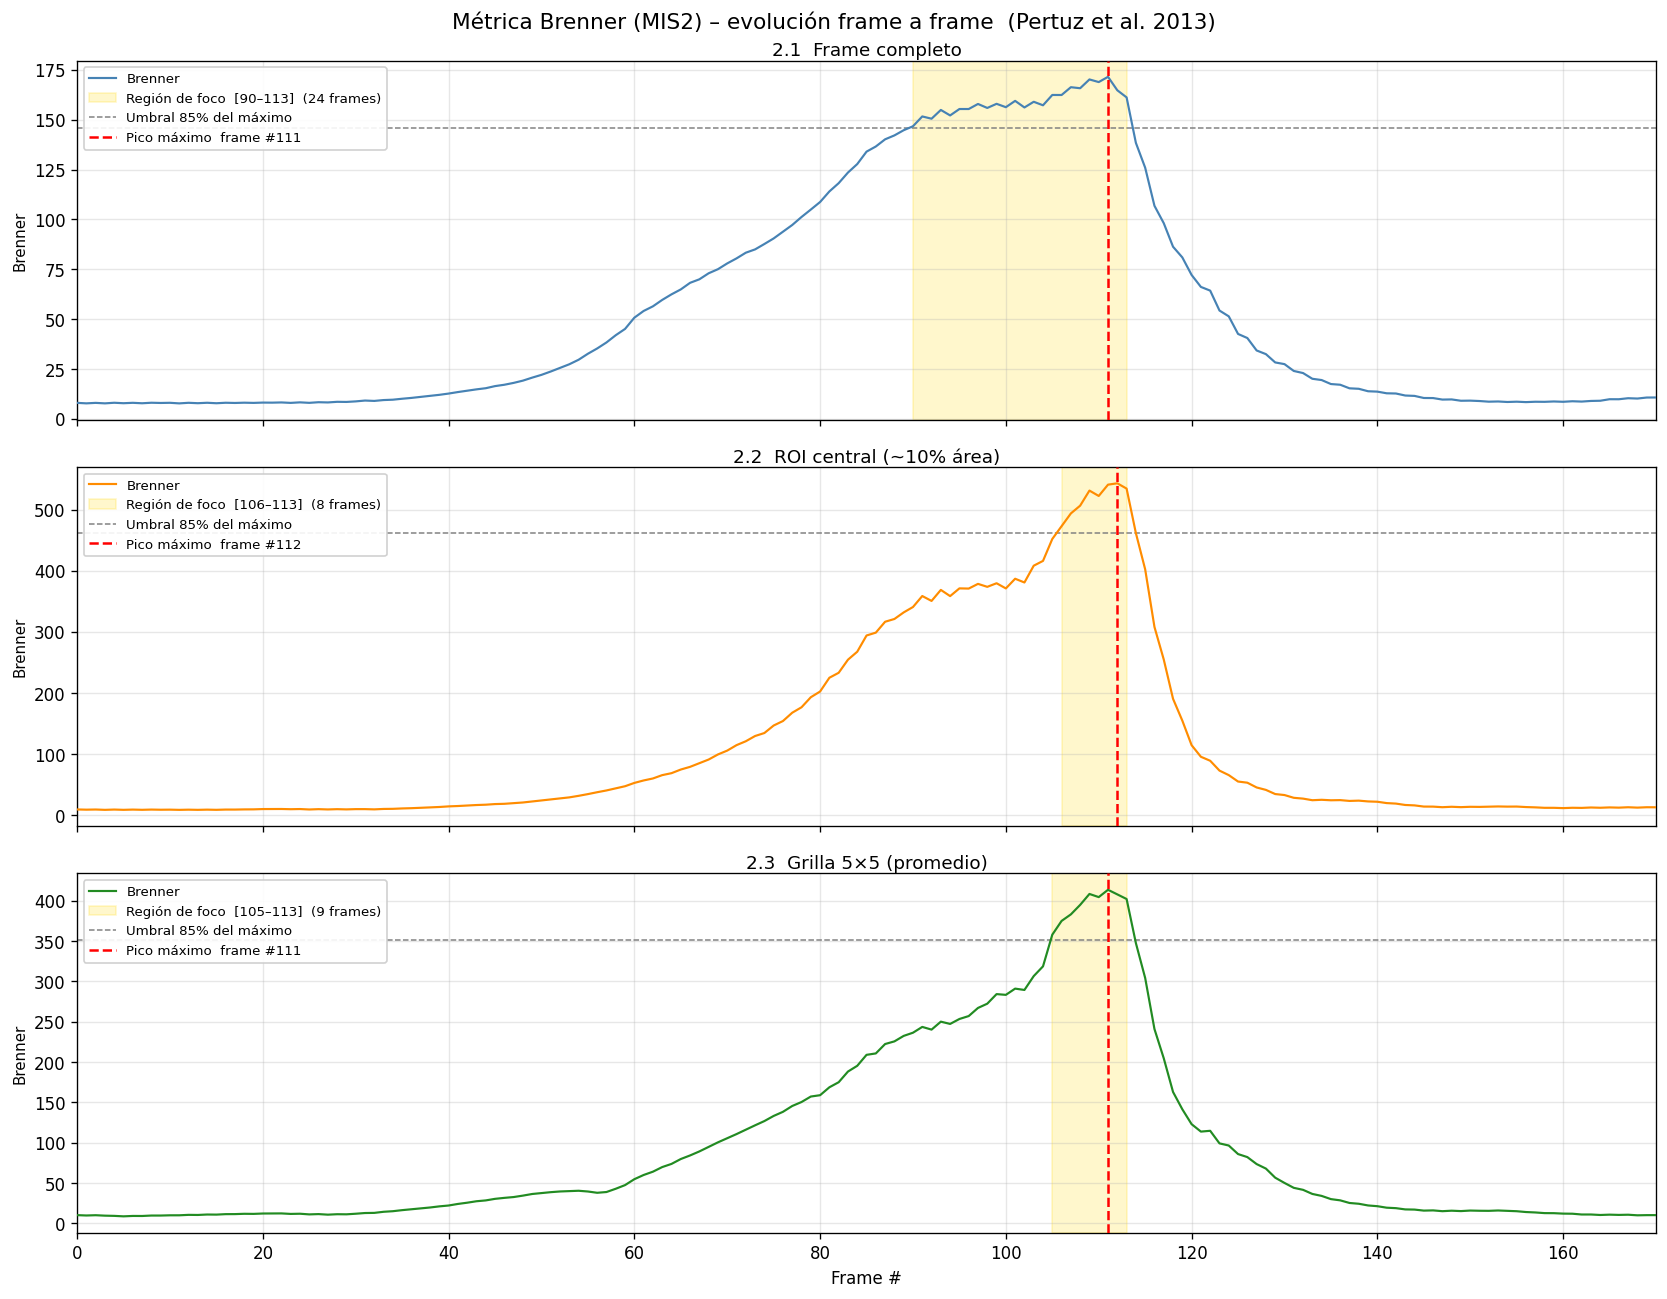

Guardado: tp2_exp2_curvas.png


In [15]:
configs_br = [
    (br_full, '2.1  Frame completo',               'steelblue'),
    (br_roi,  '2.2  ROI central (~10% área)',      'darkorange'),
    (br_grid, f'2.3  Grilla {NR}×{NC} (promedio)', 'forestgreen'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Métrica Brenner (MIS2) – evolución frame a frame  (Pertuz et al. 2013)', fontsize=13)

for ax, (br, title, color) in zip(axes, configs_br):
    start, end, thresh = find_focus_region(br, THRESHOLD_PCT)
    peak = int(br.argmax())

    ax.plot(frames, br, color=color, lw=1.3, zorder=3, label='Brenner')

    ax.axvspan(start, end, alpha=0.20, color='gold',
               label=f'Región de foco  [{start}–{end}]  ({end-start+1} frames)')

    ax.axhline(thresh, color='gray', lw=0.9, ls='--', zorder=2,
               label=f'Umbral {THRESHOLD_PCT:.0%} del máximo')

    ax.axvline(peak, color='red', lw=1.5, ls='--', zorder=4,
               label=f'Pico máximo  frame #{peak}')

    ax.set_title(title, fontsize=11, pad=3)
    ax.set_ylabel('Brenner', fontsize=9)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
    ax.set_xlim(0, len(frames) - 1)

axes[-1].set_xlabel('Frame #', fontsize=10)
plt.tight_layout()
plt.savefig('tp2_exp2_curvas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: tp2_exp2_curvas.png")

### Comparación directa: las 3 curvas normalizadas

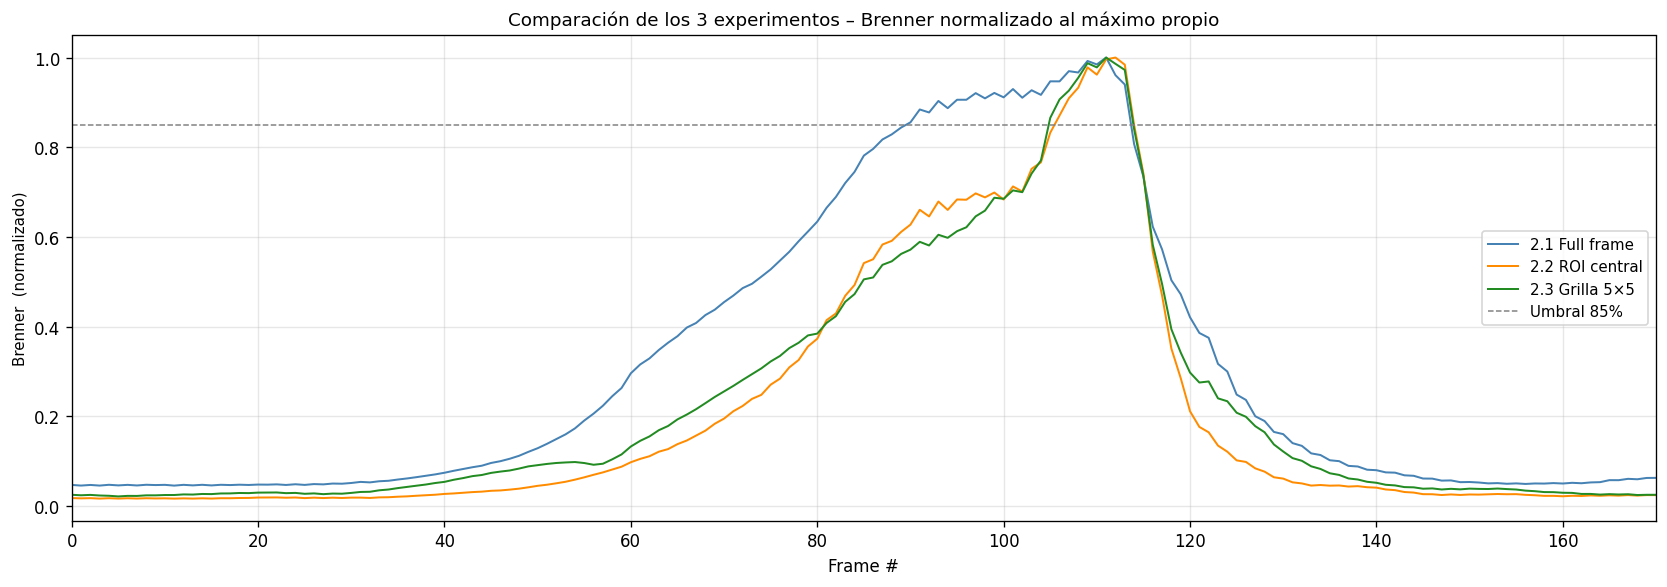

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

for br, label, color in [
    (br_full / br_full.max(), '2.1 Full frame',        'steelblue'),
    (br_roi  / br_roi.max(),  '2.2 ROI central',       'darkorange'),
    (br_grid / br_grid.max(), f'2.3 Grilla {NR}×{NC}', 'forestgreen'),
]:
    ax.plot(frames, br, lw=1.2, label=label, color=color)

ax.axhline(THRESHOLD_PCT, color='gray', ls='--', lw=0.9,
           label=f'Umbral {THRESHOLD_PCT:.0%}')
ax.set_xlabel('Frame #', fontsize=10)
ax.set_ylabel('Brenner  (normalizado)', fontsize=9)
ax.set_title('Comparación de los 3 experimentos – Brenner normalizado al máximo propio', fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, len(frames) - 1)
plt.tight_layout()
plt.savefig('tp2_exp2_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

Las curvas son claramente más similares entre sí

## Resumen de resultados y frame del pico de enfoque

In [17]:
print("=" * 62)
print(f"{'Experimento':<22} {'Peak':>6}  {'Brenner max':>12}  {'Región de foco':>16}")
print("=" * 62)
for name, br in [("Full frame", br_full), ("ROI central", br_roi), ("Grilla 5×5", br_grid)]:
    s, e, _ = find_focus_region(br, THRESHOLD_PCT)
    print(f"{name:<22} {br.argmax():>6d}  {br.max():>12.2f}  [{s:>4d} – {e:>4d}] ({e-s+1} frames)")
print("=" * 62)
print(f"\nUmbral: Brenner ≥ {THRESHOLD_PCT:.0%} del máximo")
print(f"Video:  {len(frames)} frames @ {FPS:.1f} fps  →  {len(frames)/FPS:.1f} s")

Experimento              Peak   Brenner max    Región de foco
Full frame                111        171.50  [  90 –  113] (24 frames)
ROI central               112        543.09  [ 106 –  113] (8 frames)
Grilla 5×5                111        413.41  [ 105 –  113] (9 frames)

Umbral: Brenner ≥ 85% del máximo
Video:  171 frames @ 30.0 fps  →  5.7 s


### Unsharp Masking aplicado a Brenner

Mismo procedimiento que el punto opcional anterior, evaluando los frames procesados con la métrica de Brenner.

Los parámetros `THRESH_LOW`, `THRESH_HIGH`, `SIGMA`, `AMOUNT` y `make_barely_mask` son los mismos ya definidos.

In [18]:
mask_br_full = make_barely_mask(br_full)
mask_br_roi  = make_barely_mask(br_roi)
mask_br_grid = make_barely_mask(br_grid)

for name, mask in [("Full", mask_br_full), ("ROI", mask_br_roi), ("Grid", mask_br_grid)]:
    print(f"{name:<6}: {mask.sum():>3} frames con masking (Brenner)")

br_unsharp_full = br_full.copy()
br_unsharp_roi  = br_roi.copy()
br_unsharp_grid = br_grid.copy()

x1r, y1r, x2r, y2r = ROI
needs_br = mask_br_full | mask_br_roi | mask_br_grid

cap = cv2.VideoCapture(VIDEO_PATH)
for i in range(len(frames)):
    ret, frame = cap.read()
    if not ret:
        break
    if not needs_br[i]:
        continue

    if mask_br_full[i]:
        val = compute_Brenner(unsharp_mask(frame, SIGMA, AMOUNT))
        br_unsharp_full[i] = min(val, br_full.max())

    if mask_br_roi[i]:
        val = compute_Brenner(unsharp_mask(frame[y1r:y2r, x1r:x2r], SIGMA, AMOUNT))
        br_unsharp_roi[i] = min(val, br_roi.max())

    if mask_br_grid[i]:
        sharp  = unsharp_mask(frame, SIGMA, AMOUNT)
        scores = [compute_Brenner(sharp[y1:y2, x1:x2]) for (x1, y1, x2, y2) in BLOCKS]
        br_unsharp_grid[i] = min(float(np.mean(scores)), br_grid.max())

cap.release()
print("ok")

Full  :  18 frames con masking (Brenner)
ROI   :   3 frames con masking (Brenner)
Grid  :   3 frames con masking (Brenner)
ok


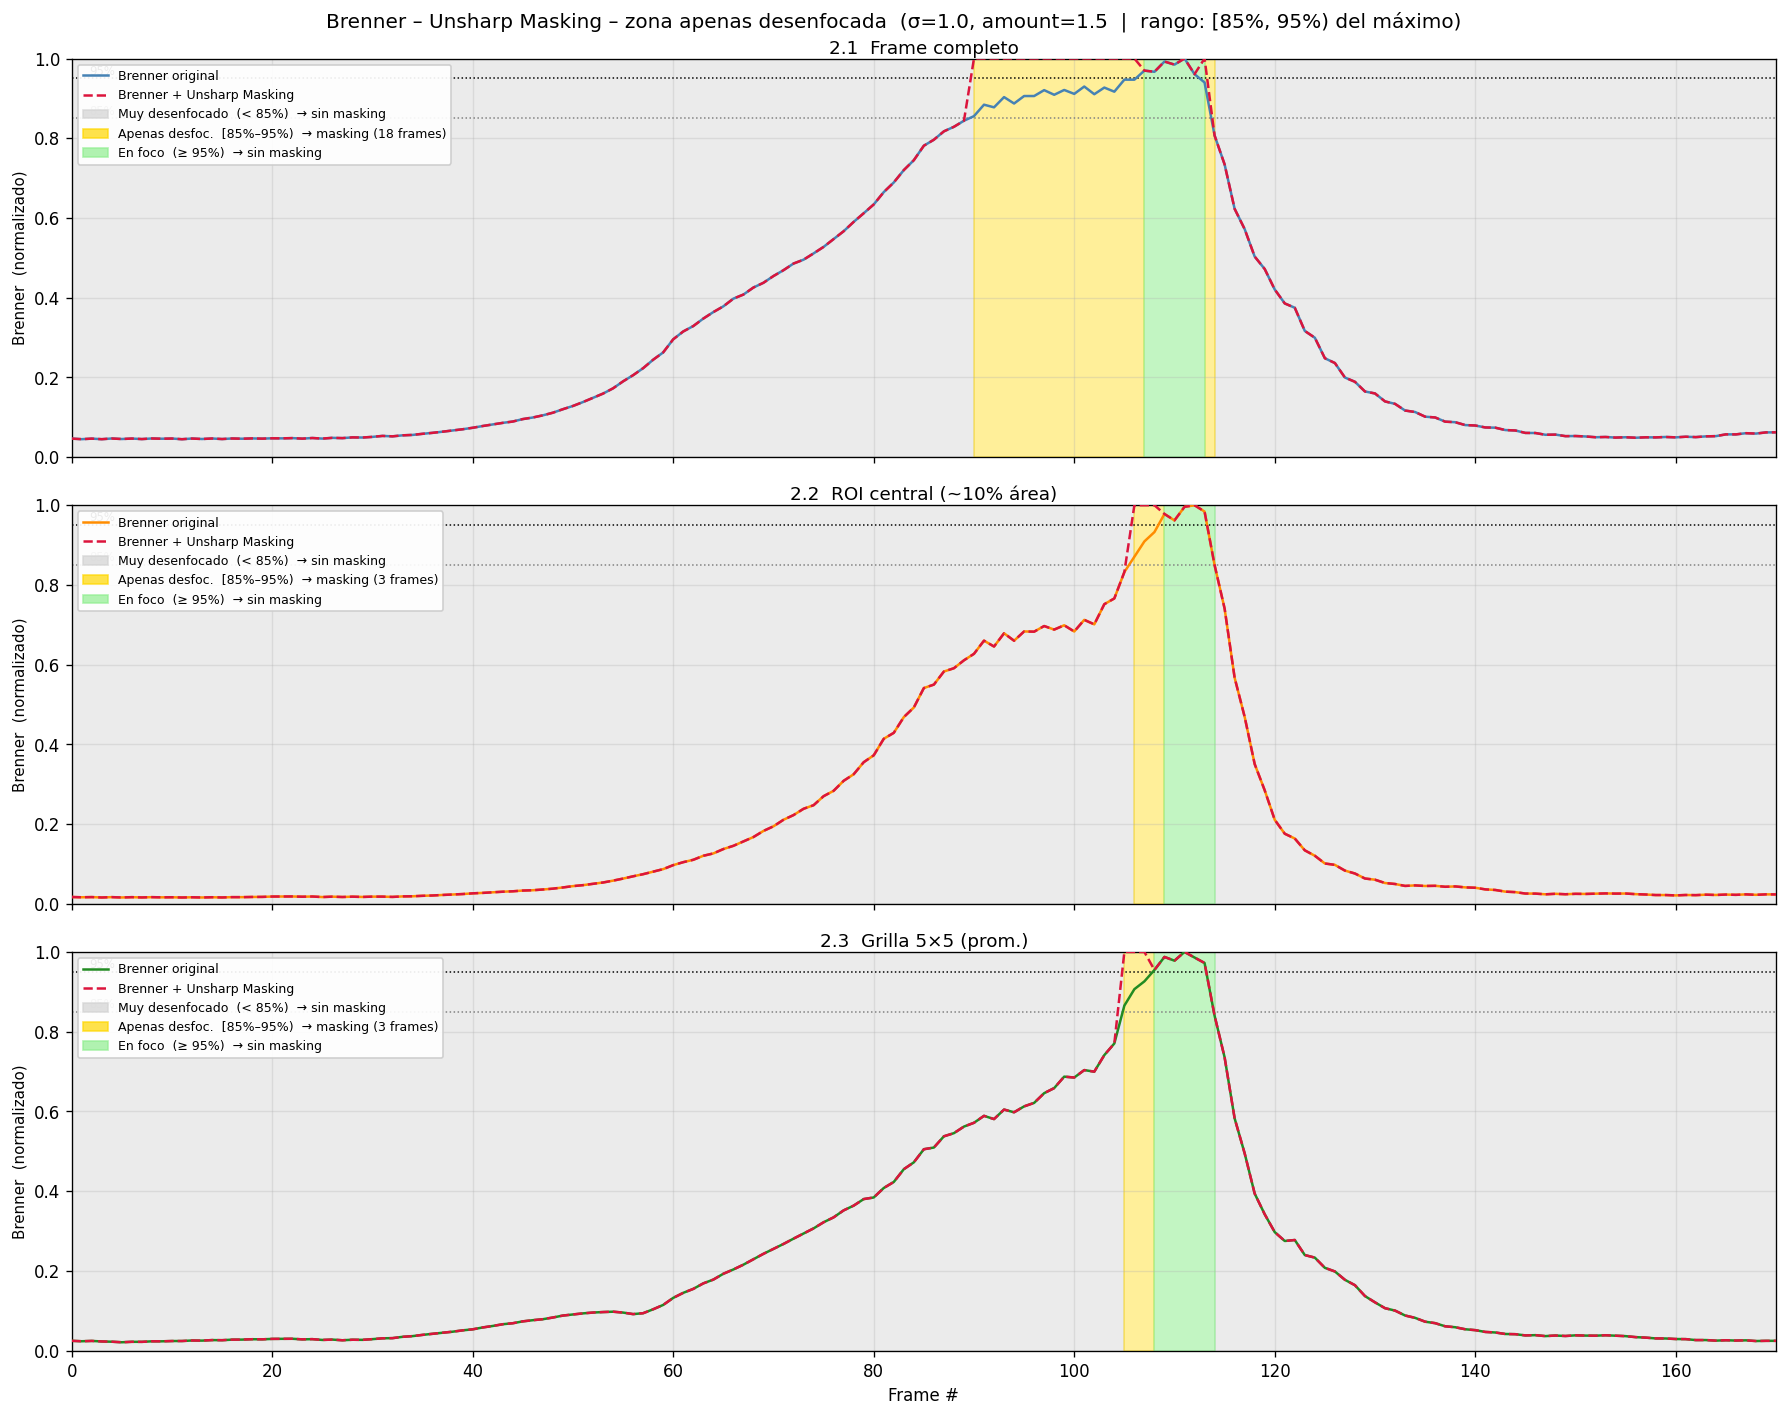

Guardado: tp2_brenner_unsharp.png


In [19]:
experiments_br_u = [
    ('2.1  Frame completo',            br_full,  br_unsharp_full, mask_br_full,  'steelblue'),
    ('2.2  ROI central (~10% área)',    br_roi,   br_unsharp_roi,  mask_br_roi,   'darkorange'),
    (f'2.3  Grilla {NR}×{NC} (prom.)', br_grid,  br_unsharp_grid, mask_br_grid,  'forestgreen'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle(
    f'Brenner – Unsharp Masking – zona apenas desenfocada  '
    f'(σ={SIGMA}, amount={AMOUNT}  |  rango: [{THRESH_LOW:.0%}, {THRESH_HIGH:.0%}) del máximo)',
    fontsize=12
)

for ax, (title, br_orig, br_sharp, mask, color) in zip(axes, experiments_br_u):
    mx = br_orig.max()
    norm_orig  = br_orig  / mx
    norm_sharp = br_sharp / mx

    for s, e in contiguous_spans(br_orig < THRESH_LOW * mx):
        ax.axvspan(s, e + 1, color='lightgray',  alpha=0.45, zorder=0)
    for s, e in contiguous_spans(mask):
        ax.axvspan(s, e + 1, color='gold',       alpha=0.40, zorder=0)
    for s, e in contiguous_spans(br_orig >= THRESH_HIGH * mx):
        ax.axvspan(s, e + 1, color='lightgreen', alpha=0.55, zorder=0)

    ax.plot(frames, norm_orig,  color=color,     lw=1.5, zorder=3, label='Brenner original')
    ax.plot(frames, norm_sharp, color='crimson', lw=1.5, ls='--', zorder=4,
            label='Brenner + Unsharp Masking')

    ax.axhline(THRESH_LOW,  color='gray',  lw=0.9, ls=':')
    ax.axhline(THRESH_HIGH, color='black', lw=0.9, ls=':')
    ax.text(len(frames) * 0.01, THRESH_LOW  + 0.01, f'{THRESH_LOW:.0%}',  fontsize=7, color='gray')
    ax.text(len(frames) * 0.01, THRESH_HIGH + 0.01, f'{THRESH_HIGH:.0%}', fontsize=7, color='black')

    region_patches = [
        mpatches.Patch(color='lightgray',  alpha=0.7,
                       label=f'Muy desenfocado  (< {THRESH_LOW:.0%})  → sin masking'),
        mpatches.Patch(color='gold',       alpha=0.7,
                       label=f'Apenas desfoc.  [{THRESH_LOW:.0%}–{THRESH_HIGH:.0%})  → masking ({mask.sum()} frames)'),
        mpatches.Patch(color='lightgreen', alpha=0.7,
                       label=f'En foco  (≥ {THRESH_HIGH:.0%})  → sin masking'),
    ]
    line_handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=line_handles + region_patches, fontsize=7.5, loc='upper left', framealpha=0.92)

    ax.set_title(title, fontsize=11, pad=3)
    ax.set_ylabel('Brenner  (normalizado)', fontsize=9)
    ax.set_xlim(0, len(frames) - 1)
    ax.set_ylim(0, 1.0)

axes[-1].set_xlabel('Frame #', fontsize=10)
plt.tight_layout()
plt.savefig('tp2_brenner_unsharp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: tp2_brenner_unsharp.png")

Los últimos 2 gráficos me despertaron una inquietud, parecería que el unsharp masking no estaría tomando los frames apenas desenfocados posteriores al pico de enfoque. Revisando estos valores, la métrica normalizada cae abruptamente desde 95% a menos de 85% en un frame, por lo que estaría alienada con esa definición. Voy a probar aumentando un poco la zona de "apenas desenfoque".

In [22]:
THRESH_LOW  = 0.80
THRESH_HIGH = 0.95
SIGMA  = 1.0
AMOUNT = 1.5

In [23]:
# Brenner – Unsharp masking con THRESH_LOW=0.80
mask_br_full2 = make_barely_mask(br_full)
mask_br_roi2  = make_barely_mask(br_roi)
mask_br_grid2 = make_barely_mask(br_grid)

for name, mask in [("Full", mask_br_full2), ("ROI", mask_br_roi2), ("Grid", mask_br_grid2)]:
    print(f"{name:<6}: {mask.sum():>3} frames con masking (Brenner, nuevo umbral)")

br_unsharp_full2 = br_full.copy()
br_unsharp_roi2  = br_roi.copy()
br_unsharp_grid2 = br_grid.copy()

x1r, y1r, x2r, y2r = ROI
needs_br2 = mask_br_full2 | mask_br_roi2 | mask_br_grid2

cap = cv2.VideoCapture(VIDEO_PATH)
for i in range(len(frames)):
    ret, frame = cap.read()
    if not ret:
        break
    if not needs_br2[i]:
        continue

    if mask_br_full2[i]:
        val = compute_Brenner(unsharp_mask(frame, SIGMA, AMOUNT))
        br_unsharp_full2[i] = min(val, br_full.max())

    if mask_br_roi2[i]:
        val = compute_Brenner(unsharp_mask(frame[y1r:y2r, x1r:x2r], SIGMA, AMOUNT))
        br_unsharp_roi2[i] = min(val, br_roi.max())

    if mask_br_grid2[i]:
        sharp  = unsharp_mask(frame, SIGMA, AMOUNT)
        scores = [compute_Brenner(sharp[y1:y2, x1:x2]) for (x1, y1, x2, y2) in BLOCKS]
        br_unsharp_grid2[i] = min(float(np.mean(scores)), br_grid.max())

cap.release()
print("Procesamiento Brenner finalizado.")

Full  :  22 frames con masking (Brenner, nuevo umbral)
ROI   :   5 frames con masking (Brenner, nuevo umbral)
Grid  :   4 frames con masking (Brenner, nuevo umbral)
Procesamiento Brenner finalizado.


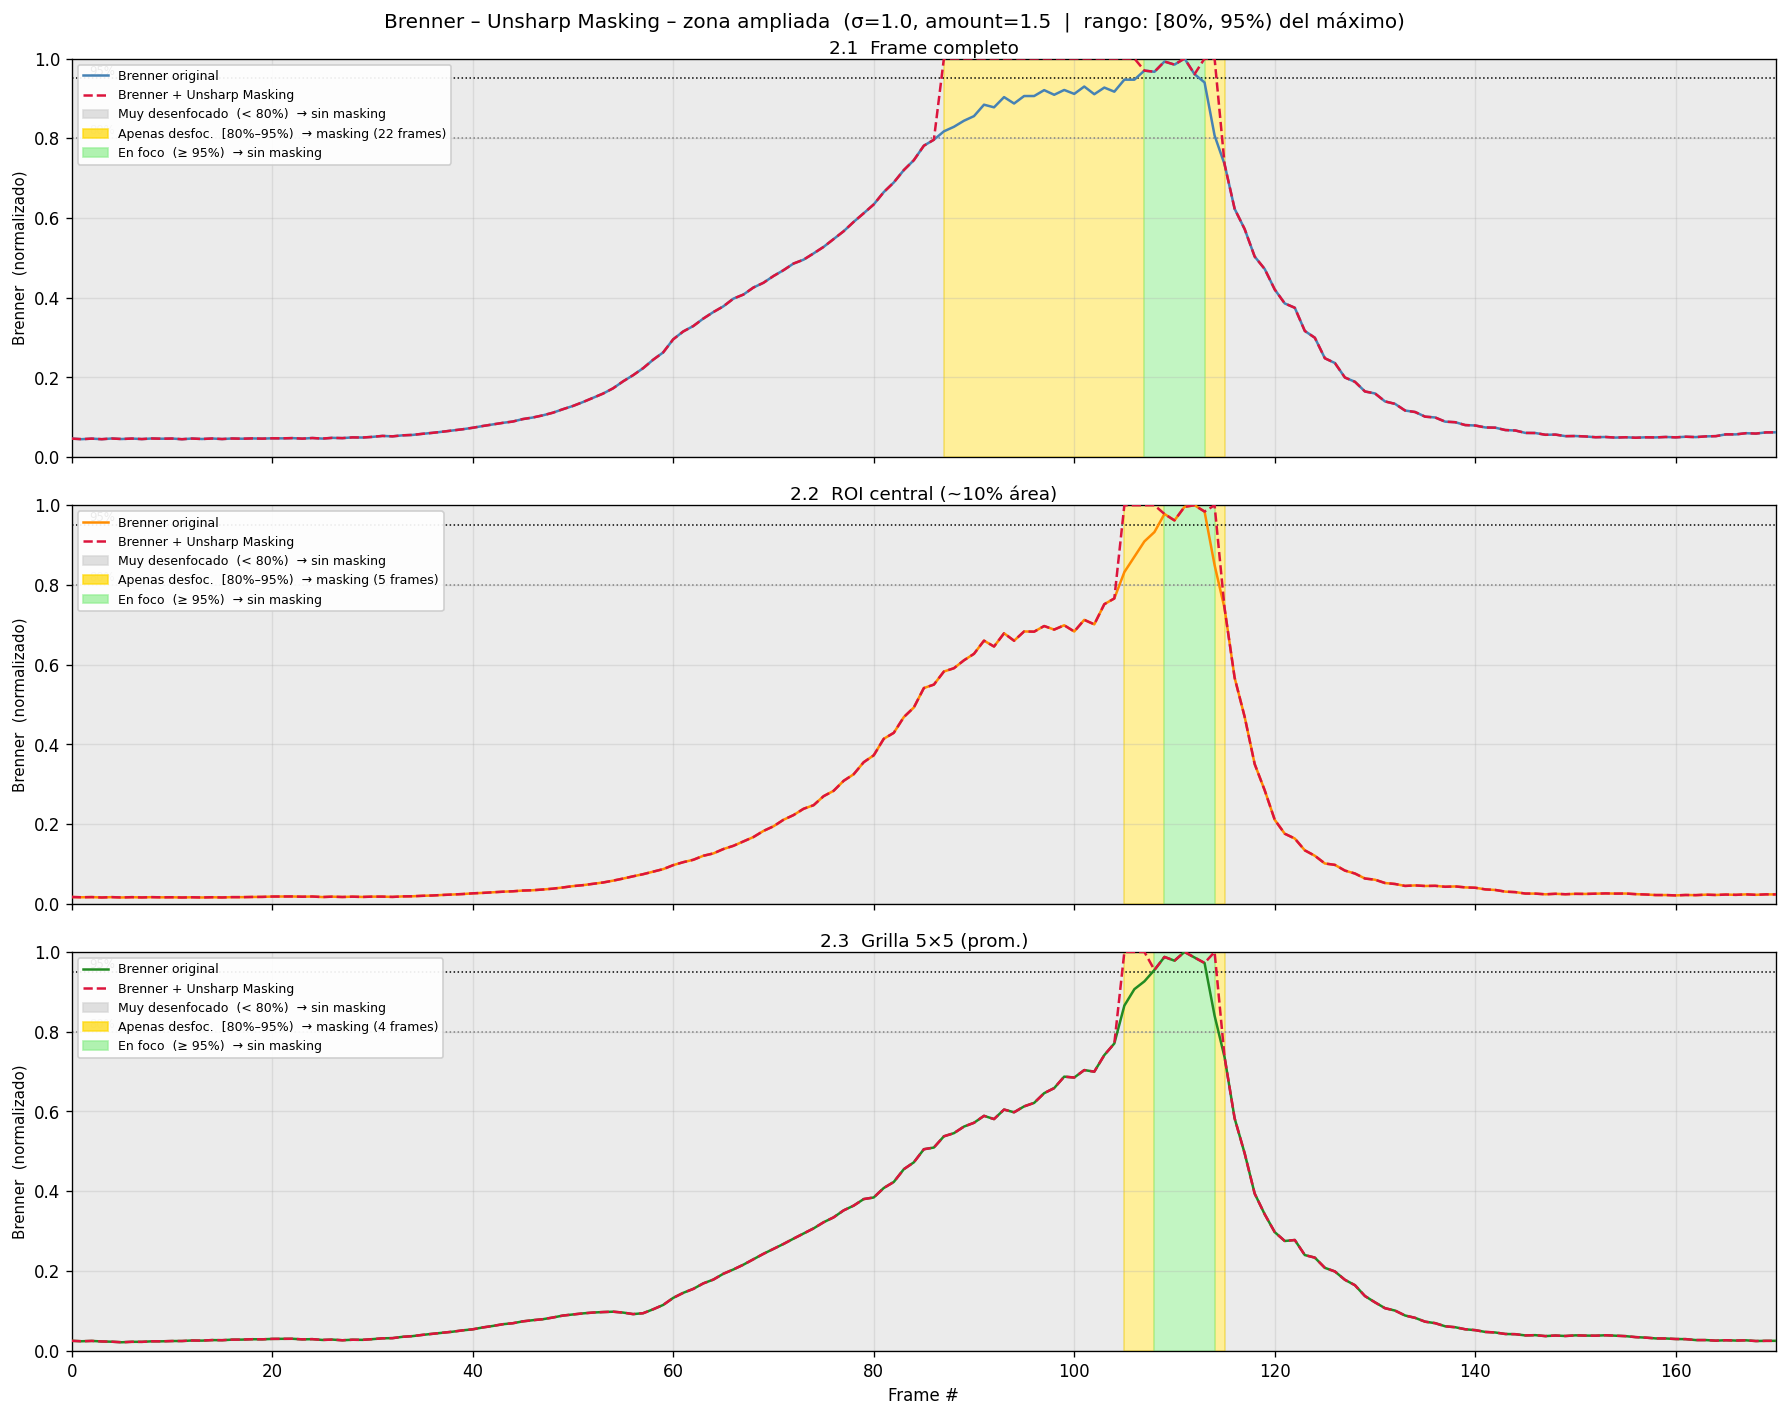

Guardado: tp2_brenner_unsharp_v2.png


In [24]:
experiments_br_u2 = [
    ('2.1  Frame completo',            br_full,  br_unsharp_full2, mask_br_full2,  'steelblue'),
    ('2.2  ROI central (~10% área)',    br_roi,   br_unsharp_roi2,  mask_br_roi2,   'darkorange'),
    (f'2.3  Grilla {NR}×{NC} (prom.)', br_grid,  br_unsharp_grid2, mask_br_grid2,  'forestgreen'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle(
    f'Brenner – Unsharp Masking – zona ampliada  '
    f'(σ={SIGMA}, amount={AMOUNT}  |  rango: [{THRESH_LOW:.0%}, {THRESH_HIGH:.0%}) del máximo)',
    fontsize=12
)

for ax, (title, br_orig, br_sharp, mask, color) in zip(axes, experiments_br_u2):
    mx = br_orig.max()
    norm_orig  = br_orig  / mx
    norm_sharp = br_sharp / mx

    for s, e in contiguous_spans(br_orig < THRESH_LOW * mx):
        ax.axvspan(s, e + 1, color='lightgray',  alpha=0.45, zorder=0)
    for s, e in contiguous_spans(mask):
        ax.axvspan(s, e + 1, color='gold',       alpha=0.40, zorder=0)
    for s, e in contiguous_spans(br_orig >= THRESH_HIGH * mx):
        ax.axvspan(s, e + 1, color='lightgreen', alpha=0.55, zorder=0)

    ax.plot(frames, norm_orig,  color=color,     lw=1.5, zorder=3, label='Brenner original')
    ax.plot(frames, norm_sharp, color='crimson', lw=1.5, ls='--', zorder=4,
            label='Brenner + Unsharp Masking')

    ax.axhline(THRESH_LOW,  color='gray',  lw=0.9, ls=':')
    ax.axhline(THRESH_HIGH, color='black', lw=0.9, ls=':')
    ax.text(len(frames) * 0.01, THRESH_LOW  + 0.01, f'{THRESH_LOW:.0%}',  fontsize=7, color='gray')
    ax.text(len(frames) * 0.01, THRESH_HIGH + 0.01, f'{THRESH_HIGH:.0%}', fontsize=7, color='black')

    region_patches = [
        mpatches.Patch(color='lightgray',  alpha=0.7,
                       label=f'Muy desenfocado  (< {THRESH_LOW:.0%})  → sin masking'),
        mpatches.Patch(color='gold',       alpha=0.7,
                       label=f'Apenas desfoc.  [{THRESH_LOW:.0%}–{THRESH_HIGH:.0%})  → masking ({mask.sum()} frames)'),
        mpatches.Patch(color='lightgreen', alpha=0.7,
                       label=f'En foco  (≥ {THRESH_HIGH:.0%})  → sin masking'),
    ]
    line_handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=line_handles + region_patches, fontsize=7.5, loc='upper left', framealpha=0.92)

    ax.set_title(title, fontsize=11, pad=3)
    ax.set_ylabel('Brenner  (normalizado)', fontsize=9)
    ax.set_xlim(0, len(frames) - 1)
    ax.set_ylim(0, 1.0)

axes[-1].set_xlabel('Frame #', fontsize=10)
plt.tight_layout()
plt.savefig('tp2_brenner_unsharp_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: tp2_brenner_unsharp_v2.png")

El frame de máximo enfoque difiere según la métrica y la región evaluada. En particular, la grilla 5×5 con FM detecta el pico en el frame 91, mientras que la misma grilla con Brenner lo detecta en el 111. 

La diferencia se explica por la naturaleza de cada métrica: Brenner mide diferencias de intensidad en el dominio espacial (sensible a bordes locales nítidos), mientras que FM evalúa la energía relativa en frecuencias altas vía FFT (más sensible a la distribución espectral global). 

En este video, las 25 ROIs de la grilla captan distintos elementos de textura del pedal y esos elementos no alcanzan su nitidez máxima simultáneamente para los dos criterios.